In [1]:
!!git clone https://github.com/KenzyFrhat/Customer_Churn_Predictor
%cd /content/Customer_Churn_Predictor
!git pull

/content/Customer_Churn_Predictor
Already up to date.


In [2]:
import joblib 
import pandas as pd
import numpy as np
from src.feature_engineering import split_data
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
!ls -R

.:
 Customer_Churn_Predictor  'predictors\best_et.pkl'    README.md
 Data			   'predictors\best_gb.pkl'    requirments
 notebooks		   'predictors\best_log.pkl'   src

./Customer_Churn_Predictor:
Data  notebooks  README.md  requirments  src

./Customer_Churn_Predictor/Data:
cleaned  ML_ready  Raw

./Customer_Churn_Predictor/Data/cleaned:
customer_churn_cleaned.csv

./Customer_Churn_Predictor/Data/ML_ready:
processor.pkl  X_test.pkl  X_train.pkl	y_test.pkl  y_train.pkl

./Customer_Churn_Predictor/Data/Raw:
WA_Fn-UseC_-Telco-Customer-Churn.csv

./Customer_Churn_Predictor/notebooks:
eda.ipynb

./Customer_Churn_Predictor/requirments:
requirements.txt

./Customer_Churn_Predictor/src:
feature_engineering.py	predictor.py  preprocessing.py

./Data:
cleaned  ML_ready  Raw

./Data/cleaned:
customer_churn_cleaned.csv

./Data/ML_ready:
processor.pkl  X_test.pkl  X_train.pkl	y_test.pkl  y_train.pkl

./Data/Raw:
WA_Fn-UseC_-Telco-Customer-Churn.csv

./notebooks:
eda.ipynb

./requirments:
requirements

In [4]:
df = pd.read_csv(r"./Data/cleaned/customer_churn_cleaned.csv")
original_X_train , original_X_test, _ , _  =  split_data(df)

In [5]:
X_test = joblib.load(r"./Data/ML_ready/X_test.pkl")
y_test = joblib.load(r"./Data/ML_ready/y_test.pkl")
y_train = joblib.load(r"./Data/ML_ready/y_train.pkl")

In [6]:
log_clf = joblib.load(r".\predictors\best_log.pkl")
et_clf = joblib.load(r".\predictors\best_et.pkl")
gb_clf = joblib.load(r".\predictors\best_gb.pkl")

In [7]:
predictors = [log_clf, et_clf, gb_clf]

In [8]:
def create_model_error_comparison(original_X_test, X_test, y_test, predictors):
    X_test_error_analysis = original_X_test.copy()
    X_test_error_analysis["true_pred"] = y_test.copy()
    
    for prodictor in predictors:
        y_pred = prodictor.predict(X_test)
        fn_mask = (y_pred == 0) & (y_test == 1)
        fp_mask = (y_pred == 1) & (y_test == 0)
        X_test_error_analysis[f"{type(prodictor.model).__name__}_fn"] = fn_mask
        X_test_error_analysis[f"{type(prodictor.model).__name__}_fp"] = fp_mask

    return X_test_error_analysis

In [9]:
X_test_error_analysis = create_model_error_comparison(original_X_test, X_test, y_test, predictors)


In [10]:
def num_cols_error_analysis(X_analysis , num_cols : list, predictor : list):
    model_name = type(predictor.model).__name__
    fn_mask = X_analysis[f"{model_name}_fn"]
    fp_mask = X_analysis[f"{model_name}_fp"]

    cols = len(num_cols) 
    fig, axes = plt.subplots(
    1,
    cols,
    figsize=(5 * cols, 5)
)

    for i, col in enumerate(num_cols):
        sns.histplot(
            x = X_analysis[col] , 
            kde = True, 
            color = "steelblue", 
            label = "Original", 
            stat = "density",
            ax = axes[i]
        )
            
        sns.histplot(
            x = X_analysis.loc[fn_mask, col] , 
            kde = True, 
            color = "red", 
            label = "FN", 
            stat = "density",
            ax = axes[i]
        )

        sns.histplot(
                x = X_analysis.loc[fp_mask, col] , 
                kde = True, 
                color = "yellow", 
                label = "FP", 
                stat = "density",
                ax = axes[i]
            )

    plt.title(f"{model_name}")

    plt.show()




In [11]:
def num_cols_error_comparison(X_analysis , num_cols : list, predictors : list):
    for predictor in predictors:
        num_cols_error_analysis(X_analysis, num_cols, predictor)


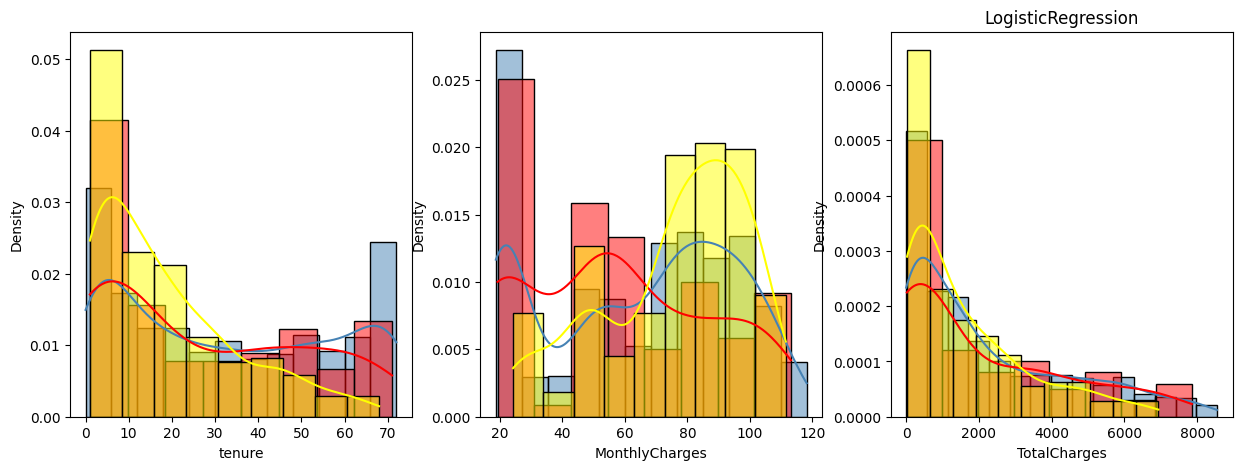

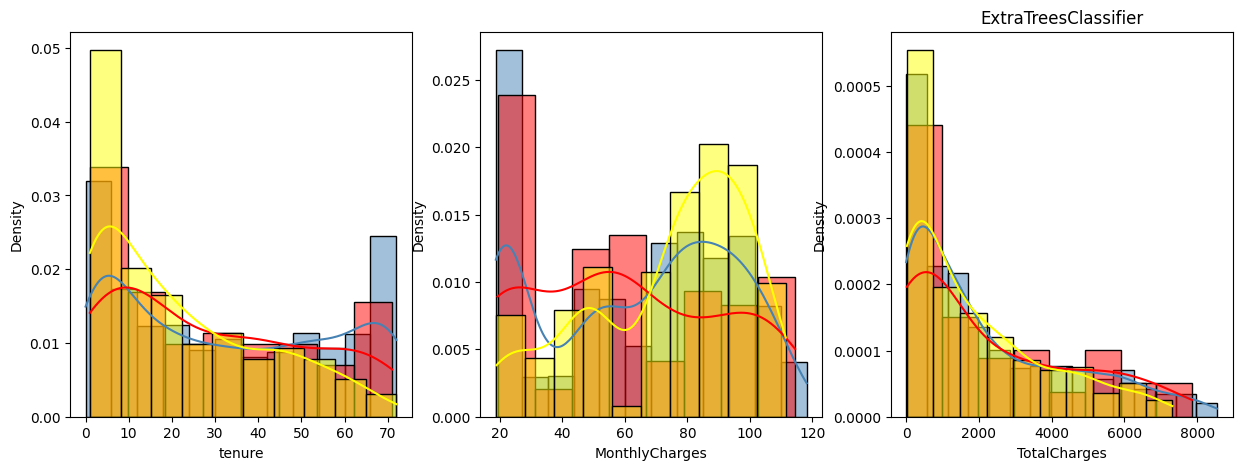

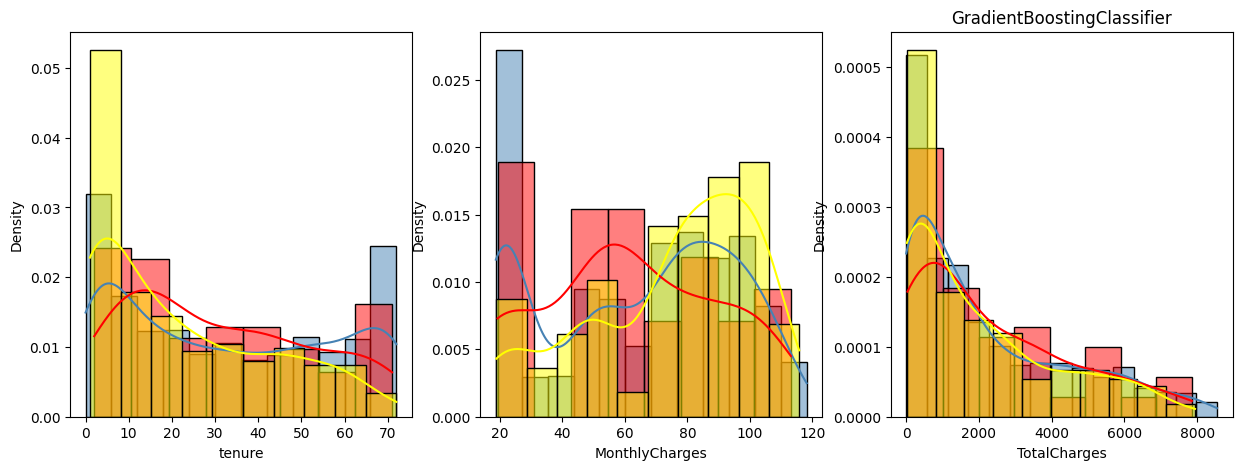

In [12]:
NUMERICAL_COLS = ["tenure", "MonthlyCharges", "TotalCharges"]
num_cols_error_comparison(X_test_error_analysis, NUMERICAL_COLS, predictors )
